In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

In [3]:
model = load_model("../models/fer_model.keras")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [5]:
IMG_SIZE = 48
BATCH_SIZE = 32

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    "../dataset/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 7178 images belonging to 7 classes.


In [6]:
print(test_generator.class_indices)

{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [7]:
predictions = model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)

y_true = test_generator.classes

225/225 ━━━━━━━━━━━━━━━━━━━━ 95s 422ms/step


In [ ]:
accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 57.69%


In [9]:
class_names = list(test_generator.class_indices.keys())

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

       angry       0.51      0.47      0.49       958
     disgust       0.85      0.20      0.32       111
        fear       0.42      0.30      0.35      1024
       happy       0.78      0.79      0.79      1774
     neutral       0.51      0.60      0.55      1233
         sad       0.43      0.50      0.47      1247
    surprise       0.69      0.72      0.71       831

    accuracy                           0.58      7178
   macro avg       0.60      0.51      0.52      7178
weighted avg       0.58      0.58      0.57      7178



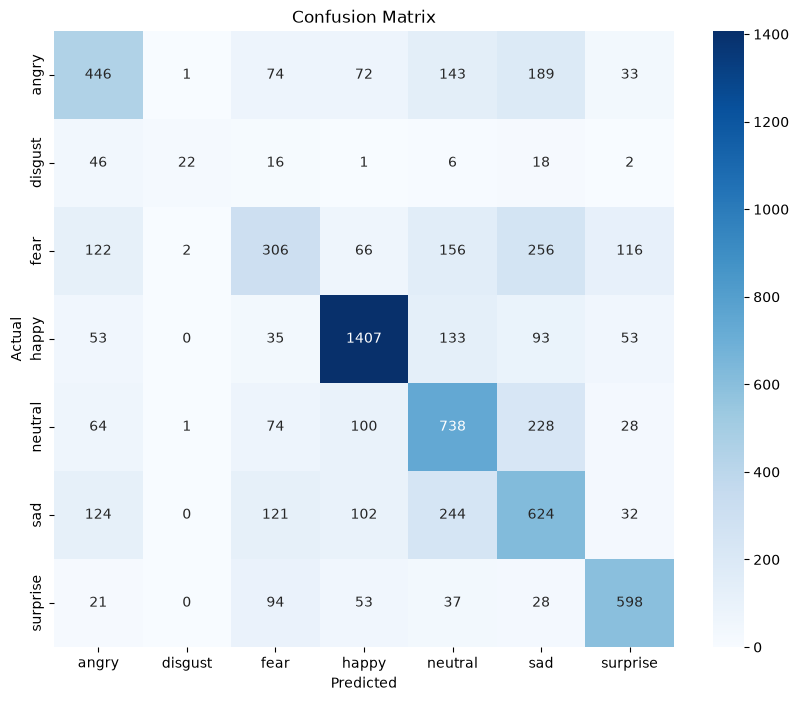

In [10]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step


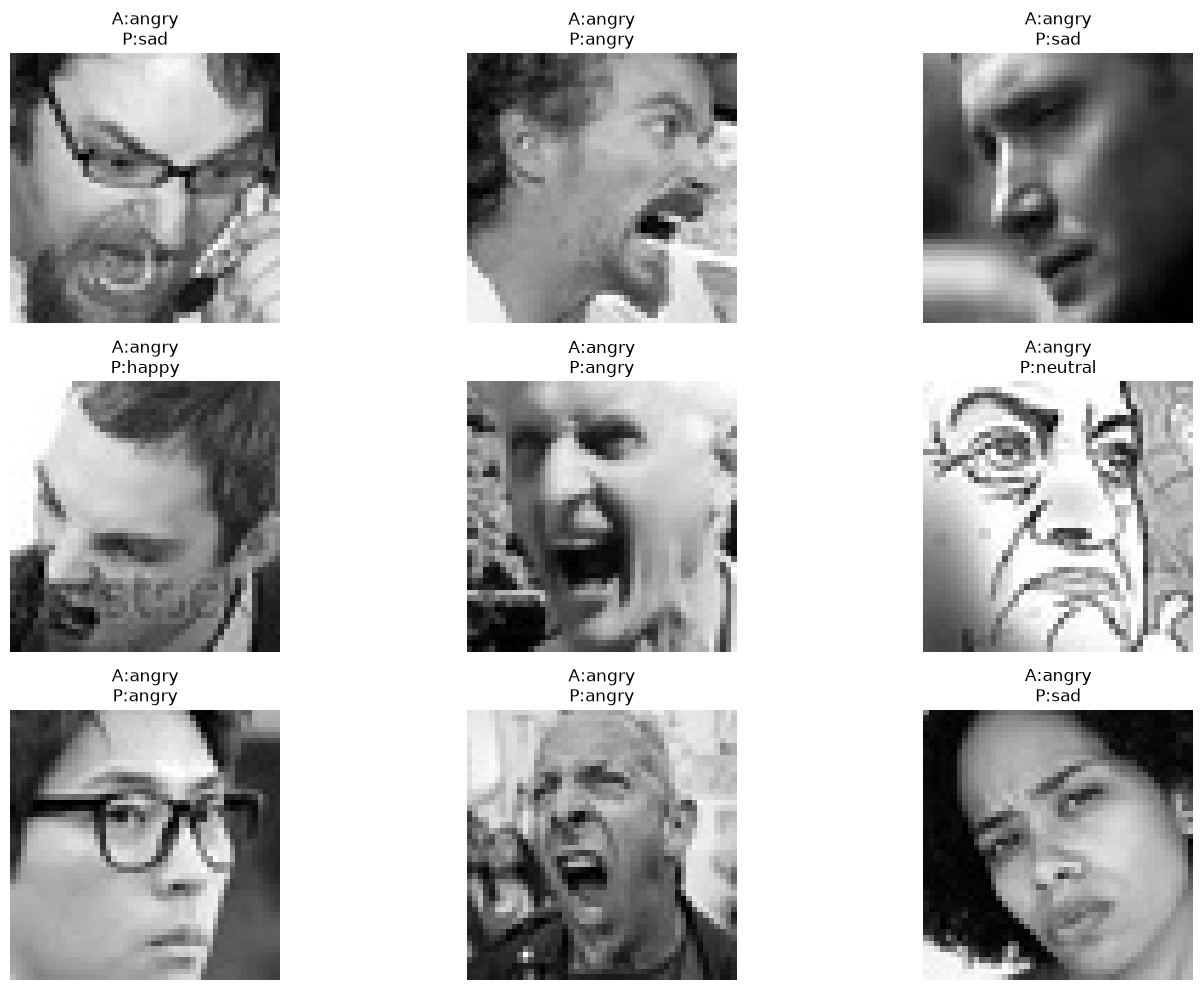

In [11]:
images, labels = next(test_generator)

preds = model.predict(images)

plt.figure(figsize=(15, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)

    plt.imshow(images[i].squeeze(), cmap="gray")

    actual = class_names[np.argmax(labels[i])]
    predicted = class_names[np.argmax(preds[i])]

    plt.title(f"A:{actual}\nP:{predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
with open("evaluation_results.txt", "w") as f:
    f.write(f"Test Accuracy: {accuracy * 100:.2f}%\n\n")

    f.write(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names
        )
    )